# Stanford CME 241 (Winter 2026) - Assignment 3

**Due: Friday, February 27 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/Sondringsen/RL-book/blob/master/assignment_3/assignment3.ipynb

*Group members (replace below names with people in your group):* 
- Sam Layton
- Siddhant Sukhani
- Sondre Rogde

## Imports

In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.integrate import quad
from typing import Iterable, Iterator, Mapping, TypeVar, Callable, Sequence, Tuple, Dict
from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovRewardProcess
from rl.chapter10.prediction_utils import compare_td_and_mc
X = TypeVar('X')
S = TypeVar('S')

## Question 1: Milk Vendor Optimization Problem (Led by ______)

You are a milk vendor and your task is to bring to your store a supply (denoted $S \in \mathbb{R}$) of milk volume in the morning that will give you the best profits. You know that the demand for milk throughout the course of the day is a probability distribution function $f$ (for mathematical convenience, assume people can buy milk in volumes that are real numbers, hence milk demand $x \in \mathbb{R}$ is a continuous variable with a probability density function). 

For every extra gallon of milk you carry at the end of the day (supply $S$ exceeds random demand $x$), you incur a cost of $h$ (effectively the wasteful purchases amounting to the difference between your purchase price and the end-of-day discount disposal price since you are not allowed to sell the same milk the next day). For every gallon of milk that a customer demands that you don’t carry (random demand $x$ exceeds supply $S$), you incur a cost of $p$ (effectively the missed sales revenue amounting to the difference between your sales price and purchase price). 

Your task is to identify the optimal supply $S$ that minimizes your **Expected Cost** $g(S)$, given by:

$$
g_1(S) = \mathbb{E}[\max(x - S, 0)] = \int_{S}^{\infty} (x - S) \cdot f(x) \, dx
$$

$$
g_2(S) = \mathbb{E}[\max(S - x, 0)] = \int_{-\infty}^{S} (S - x) \cdot f(x) \, dx
$$

$$
g(S) = p \cdot g_1(S) + h \cdot g_2(S)
$$

---

### Part (A): Analytical Optimization

1. **Derive the first-order condition (FOC)** for minimizing the expected cost $g(S)$.
2. **Solve the FOC** to express the optimal supply $S^*$ in terms of the given parameters: $p$, $h$, and the demand distribution $f(x)$. (*Hint*: Pay attention to the balance between the costs of overstocking and understocking)

3. **Interpretation**: Provide an interpretation of the condition you derived. What does the balance between $p$ and $h$ imply about the optimal supply $S^*$?

---

### Part (B): Special Case Analysis

1. Consider the case where the demand $x$ follows an **exponential distribution** with parameter $\lambda > 0$. That is, $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$.
    - Derive an explicit expression for the optimal supply $S^*$.
    
2. Consider the case where the demand $x$ follows a **normal distribution** with mean $\mu$ and variance $\sigma^2$, i.e., $x \sim \mathcal{N}(\mu, \sigma^2)$. 
    - Set up the integral for $g(S)$ and describe how it relates to the **cumulative distribution function (CDF)** of the normal distribution.
    - Provide an interpretation of how changes in $\mu$ and $\sigma$ influence the optimal $S^*$. 

---

### Part (C): Framing as a Financial Options Problem

1. Frame the milk vendor’s problem as a **portfolio of call and put options**:
    - Identify the analog of the “strike price” and “underlying asset.”
    - Explain which part of the cost function $g_1(S)$ or $g_2(S)$ corresponds to a call option and which part to a put option.
    - What do $p$ and $h$ represent in this options framework?

2. Explain how this framing could be used to derive the optimal supply $S^*$ if solved using financial engineering concepts.

---

### Part (D): Numerical Solution and Simulation

1. **Numerical Solution**: Write a Python function that numerically estimates the optimal $S^*$ using an iterative search or numerical optimization method. 

2. **Simulation**: Generate random samples of milk demand from an exponential distribution and simulate the total costs for different values of $S$. Plot the costs against $S$ and visually identify the optimal $S$.

### Part (A) Answer

**Part 1**

We first calculate $g_1(S)$. Let $L(S,x) = (x-S)f(x)$, so we get $g_1(S) = p\int_{a(S)}^{b(S)}  L(S, x)dx$ where $a(S) = S$ and $b(S)=\infty$. We now use Leibniz integral rule:

$$
\frac{d}{dS}g_1(S) =p \bigg( L(S, b(S))\frac{d}{dS}b(S) - L(S, a(S))\frac{d}{dS}a(S) + \int_{a(S)}^{b(S)} \frac{\partial}{\partial S} L(S, x)dx\bigg)
$$

We have that $\frac{d}{dS}b(S) = 0$ and $\frac{d}{dS}a(S) = 1$ and $\frac{\partial}{\partial S} L(S, x) = -f(x)$ so plugging in we get:

$$
\frac{d}{dS}g_1(S) =p \bigg( 0 - 0 - \int_{a(S)}^{b(S)} f(x) dx\bigg)\\
\frac{d}{dS}g_1(S) =-p \bigg(\int_{s}^{\infty} f(x) dx\bigg)\\
\frac{d}{dS}g_1(S) =-p ( 1-F(S))
$$

Here $F$ is the cdf of the demand which is the antiderivative of $f$. We do the same for $g_2(S)$ but now we let $L(S,x) = (S-x)f(x)$ and $a(S) = -\infty$ and $b(S)=S$. After some algebra this yields:
$$
\frac{d}{dS}g_2(S) = h\int_{-\infty}^S f(x)dx = hF(S)
$$

Putting it together and equating to zero we get the first order condition:
$$
\boxed{
\frac{d}{dS}g(S) = -p ( 1-F(S)) + hF(S) = 0
}
$$

**Part 2**

Now solving for optimal $S=S^*$:

$$
-p ( 1-F(S) ) + hF(S) = 0 \implies
\boxed{
S^*=F^{-1}\bigg(\frac{p}{p+h}\bigg)
}
$$

**Part3**

We know that the CDF $F$ is a monotonically increasing function with values in the interval $[0,1]$. Increasing $p$ leads to a higher supply which makes sense because the cost of not meeting demand is high. The opposite is true for high $h$.

In the limit we have the following:
$$
\lim_{p\uparrow\infty}S^* = \lim_{p\uparrow\infty} F^{-1}\bigg(\frac{p}{p+h}\bigg) = F^{-1}(1) = \infty\\
\lim_{h\uparrow\infty}S^* = \lim_{h\uparrow\infty} F^{-1}\bigg(\frac{p}{p+h}\bigg) = F^{-1}(0) = 0
$$
This means that if $p$ grows to $\infty$ we should have $\infty$ supply as the cost of not meeting demand is so high. If $h$ goes to $\infty$ the cost of having too much is so high that the optimal supply is $0$.


### Part (B) Answer
**Part 1**

First note that the cdf of the exponential distribution is $F(x) =1 -e^{-\lambda x}$. After some algebra we find the inverse of the cdf to be:
$$
F^{-1}(y) = -\frac{\log(1-y)}{\lambda}
$$
Now plugging in $y=\frac{p}{p+h}$ yields:
$$
\boxed{
F^{-1}(\frac{p}{p+h}) = -\frac{\log(1-\frac{p}{p+h})}{\lambda} = -\frac{\log(\frac{h}{p+h})}{\lambda}
}
$$

**Part 2**

<!-- Let $\Phi(x; \mu, \sigma^2)$ denote the cdf of a normal distribution with mean $\mu$ and variance $\sigma^2$. Written on integral form this is:
$$
\Phi(x; \mu, \sigma^2) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{1}{2}\big( \frac{x-\mu}{\sigma} \big)^2}dx
$$
Now let $\Phi^{-1}(y; \mu, \sigma^2)$ be the function that solves this equaction w.r.t. $x$. Then we have that the optimal $S^*$ is:
$$
\boxed{
    S^*=\Phi^{-1}\bigg(\frac{p}{p+h}; \mu, \sigma^2\bigg)
}
$$ -->
Let  $\phi(x; \mu, \sigma^2)$ and $\Phi(x; \mu, \sigma^2)$ denote the pdf and cdf of a normal distribution with mean $\mu$ and variance $\sigma^2$ respectively. For ease of notation we will use $\phi(x) = \phi(x; 0, 1)$ and $\Phi(x) = \Phi(x; 0, 1)$ Written on integral form $g$ is:
$$
g(s) = p\int_{S}^{\infty}(x-S)\phi(x; \mu, \sigma^2)dx + h\int_{-\infty}^{S}(S-x)\phi(x; \mu, \sigma^2)dx
$$
Now we standardize so let:
$$
z=\frac{x-\mu}{\sigma} \quad
z_S=\frac{S-\mu}{\sigma} \quad
x = \sigma z + \mu
$$

$$
g(s) = p\int_{z_S}^{\infty}(\sigma z + \mu -S)\phi(z)dz + h\int_{-\infty}^{z_S}(S-\sigma z - \mu)\phi(z)dz
$$
Solving this gives us an expression in terms of the pdf and cdf of the normal distribution as desired:

$$
\boxed{
g(s) = p\bigg( \sigma\phi(z_S)+(\mu-S)(1-\Phi(z_S)) \bigg)+ h\bigg( \sigma\phi(z_S)+(S-\mu)(1-\Phi(z_S)) \bigg)
}
$$
For the optimal supply $S^*$ we still have that:
$$
F(S^*) = \frac{p}{p+h} \\
\Phi\bigg(\frac{S^*-\mu}{\sigma}\bigg) = \frac{p}{p+h}\\
\frac{S^*-\mu}{\sigma} = \Phi^{-1}\bigg(\frac{p}{p+h}\bigg)\\
S^* = \mu +\sigma\Phi^{-1}\bigg(\frac{p}{p+h}\bigg)
$$
Taking the partial derivative w.r.t $\mu$ and $\sigma$ yields:

$$
\boxed{
\frac{\partial}{\partial \mu} S^* = 1 \quad
\frac{\partial}{\partial \sigma} S^* = \Phi^{-1}\bigg(\frac{p}{p+h}\bigg)
}
$$
So we have that the optimal supply is increasing in $\mu$ which makes sense as when there is increased expectation in demand then you should have more supply. For $\sigma$ it depends on the ratio $\frac{p}{p+h}$ if this ratio is big, i.e. the cost of not meeting demand is high compared to having too much, then you should have more supply. If the ratio $\frac{p}{p+h}$ is low, i.e. the cost of having too much is high compared to the cost of not meeting demand, then you should small supply. This makes sense as more uncertainty in demand makes you want to be closer in supply to the where the cost of having wrong amount of supply is lowest.


### Part (C) Answer
**Part 1**
- The strike price is the $S$, the underlying asset is the random demand $x$.
- The payoff of a call is $x-S$ where as noted above $x$ is the price of the underlying and $S$ is the strike price. This makes $g_1$ have the role of the call. Similarly the payoff of a put is $S-x$ so $g_2$ corresponds to the put.
- $p$ and $h$ represent the weights you put on the call and the put.

**Part 2**

So given portfolio weights $p$ and $h$ and a pdf for the underlying process one can use financial engineering concepts to find the optimal strike price to invest in such a portfolio comoposition. This optimal strike price would be the optimal supply $S^*$ in the milk vendor example.

### Part (D) Answer

In the plot below we see that the optimal value is at approximately $1.25$ which coincide well with the analytical result.

In [6]:
'''
fill in the code below, and then run the code in the next cell for the simulation
'''

# simulation parameters
p = 5  # Cost of understocking (per unit)
h = 2  # Cost of overstocking (per unit)
lambda_param = 1.0  # Parameter for exponential distribution

# Probability density function for demand
def demand_pdf(x):
    return lambda_param*np.exp(-lambda_param*x)

# Cumulative distribution function for demand
def demand_cdf(x):
    return 1-np.exp(-lambda_param*x)

# Expected cost function g(S)
def expected_cost(S):
    # g1(S): Understocking cost
    g1, _ = quad(lambda x: (x - S) * demand_pdf(x), S, np.inf)
    g1 = p * g1

    # g2(S): Overstocking cost (integral using CDF)
    g2, _ = quad(lambda x: (S - x) * demand_pdf(x), 0, S)
    g2 = h * g2

    return g1 + g2

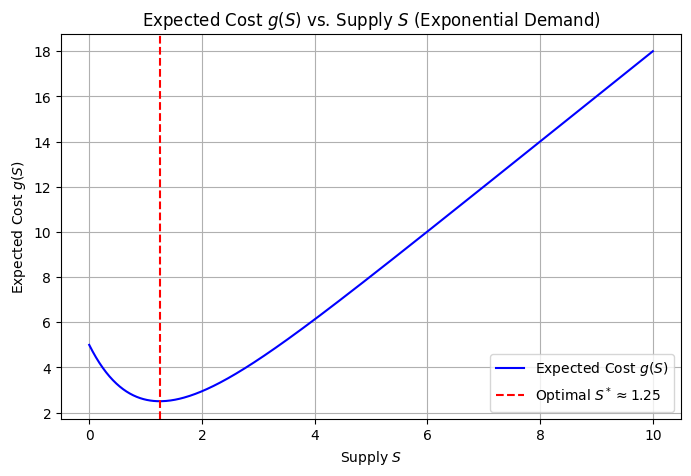

Optimal S from numerical algorithm: 1.25
Optimal S from analytical result: 1.25


In [7]:
result = minimize_scalar(expected_cost, bounds=(0, 10), method='bounded')
optimal_S = result.x

# Simulation of costs
S_values = np.linspace(0, 10, 500)
costs = [expected_cost(S) for S in S_values]

# Plotting the costs against S
plt.figure(figsize=(8, 5))
plt.plot(S_values, costs, label="Expected Cost $g(S)$", color='blue')
plt.axvline(optimal_S, color='red', linestyle='--', label=f"Optimal $S^* \\approx {optimal_S:.2f}$")
plt.xlabel("Supply $S$")
plt.ylabel("Expected Cost $g(S)$")
plt.title("Expected Cost $g(S)$ vs. Supply $S$ (Exponential Demand)")
plt.legend()
plt.grid(True)
plt.show()

print(f'Optimal S from numerical algorithm: {optimal_S:.2f}')
print(f'Optimal S from analytical result: {-np.log(h/(p+h))/lambda_param:.2f}')

## Question 2: Car Sales (Led By: _____)

You must sell your car within a finite window of $N$ days. At the beginning of each day $t \in \{1, \dots, N\}$, you receive a single offer $X_t$ from a dealership, where $\{X_t\}$ are i.i.d. draws from a known continuous distribution $Q$ supported on $[m, M]$, with $0 < m < M$.

After observing $X_t$, you must immediately choose whether to **accept** or **reject** the offer:

- If you **accept** on day $t$, you sell the car immediately and receive payoff $X_t$. The process then terminates.
- If you **reject** on day $t < N$, you keep the car, pay a parking cost $c \ge 0$ at the end of that day, and proceed to day $t+1$.
- On day $N$, you must accept the offer (i.e., rejecting is not allowed).

Your objective is to maximize the expected **net payoff**, defined as the sale price minus the total parking costs paid before the sale.

---

### Part (A): MDP Modeling

Model this problem as a finite-horizon **Markov Decision Process (MDP)**. Clearly specify:

1. **States**
2. **Actions**
3. **Rewards**
4. **State-transition probabilities**
5. **Discount factor** (use $\gamma = 1$)

Also state whether this MDP is finite- or infinite-horizon, episodic or continuing, and whether it is time-homogeneous.

---

### Part (B): Structure of the Optimal Policy

Let $V_t$ denote the optimal value function when there are $t$ days remaining (before observing the offer).

1. Write down the Bellman recursion for $V_t$.
2. Show that the optimal policy is a **time-dependent threshold policy**: that is, there exists a reservation price $r_t$ such that it is optimal to accept an offer $x$ if and only if $x \ge r_t$.
3. Express the threshold $r_t$ in terms of $V_{t-1}$ and $c$.

(You may leave expectations with respect to $Q$ written in integral or expectation form. A closed-form solution for general $Q$ is not required.)

---

### Part (C): Special Case (No Integrals)

Now consider the special case where $c = 0$ and $Q = \text{Uniform}[m, M]$.

1. Write the recursion for $V_t$ explicitly.
2. Provide the optimal policy in as closed-form a way as possible. Your policy may depend on recursively defined coefficients, but your final expressions should contain **no integrals**.


### Part (A) Answer

We model this as a **finite-horizon, episodic, non-time-homogeneous** MDP with $\gamma = 1$.

**1. States:**  
The state at time $t$ is the pair $(t, x)$ where $t \in \{1, \dots, N\}$ is the current day and $x \in [m, M]$ is the offer observed at the start of day $t$. There is also a terminal state $s_{\text{sold}}$ representing the car having been sold.

**2. Actions:**  
$\mathcal{A}(t, x) = \{\text{accept}, \text{reject}\}$ for $t < N$, and $\mathcal{A}(N, x) = \{\text{accept}\}$ (must accept on the final day).

**3. Rewards:**  
- $\text{accept}$ from state $(t, x)$: immediate reward $= x$, transition to terminal state.  
- $\text{reject}$ from state $(t, x)$ with $t < N$: immediate reward $= -c$ (parking cost), transition to $(t+1, X_{t+1})$ with $X_{t+1} \sim Q$.

**4. State-transition probabilities:**  
- $P(s_{\text{sold}} \mid (t, x), \text{accept}) = 1$.  
- $P((t+1, x') \mid (t, x), \text{reject}) = q(x')$ where $q$ is the pdf of $Q$, for $t < N$.

**5. Discount factor:** $\gamma = 1$.

### Part (B) Answer

Let $V_t$ denote the optimal expected net payoff when there are $t$ days remaining (before observing the offer).

**1. Bellman recursion:**

Base case ($t = 1$, last day, must accept):
$$V_1 = \mathbb{E}_Q[X]$$

For $t \geq 2$: upon observing offer $X$, the agent either accepts (payoff $X$) or rejects (payoff $-c + V_{t-1}$). Taking the optimal action and then the expectation over offers:
$$\boxed{V_t = \mathbb{E}_Q\big[\max(X,\; V_{t-1} - c)\big]}$$

**2. Threshold (reservation price) policy:**

Given the recursion, the optimal decision at state $(t, x)$ is:
- Accept if $x \geq V_{t-1} - c$
- Reject if $x < V_{t-1} - c$

This is a **time-dependent threshold policy** with reservation price $r_t$. The agent accepts if and only if the current offer exceeds the threshold.

**3. Expression for the threshold:**

$$\boxed{r_t = V_{t-1} - c}$$

**Intuition:** $V_{t-1}$ is the expected future payoff (before parking costs) if we continue. Subtracting the immediate parking cost $c$ gives the net value of continuing, so we accept only when the current offer beats this continuation value.

### Part (C) Answer

With $c = 0$ and $X \sim \text{Uniform}[m, M]$, the threshold simplifies to $r_t = V_{t-1}$.

**1. Recursion for $V_t$:**

Base case: $V_1 = \mathbb{E}[X] = \dfrac{m + M}{2}$.

For $t \geq 2$, since $r_t = V_{t-1} \in [m, M]$ (verified by induction below):

$$V_t = \mathbb{E}[\max(X, V_{t-1})] = \int_m^{V_{t-1}} \frac{V_{t-1}}{M - m}\,dx + \int_{V_{t-1}}^{M} \frac{x}{M - m}\,dx$$

$$= \frac{V_{t-1}(V_{t-1} - m)}{M - m} + \frac{M^2 - V_{t-1}^2}{2(M - m)}$$

Combining and simplifying:

$$\boxed{V_t = \frac{m + M}{2} + \frac{(V_{t-1} - m)^2}{2(M - m)}}$$

One can verify $V_{t-1} \in [m, M]$ by induction: $V_1 = (m+M)/2 \in [m, M]$, and if $V_{t-1} \in [m, M]$ then $V_t \geq (m+M)/2 \geq m$ and $V_t \leq (m+M)/2 + (M-m)/2 = M$.

**2. Optimal policy:**

Accept the offer on day $t$ (with $t$ days remaining) if and only if $X_t \geq V_{t-1}$, where $V_{t-1}$ is defined by the recursion above. Since $V_t$ is non-decreasing in $t$ (having more days remaining is always weakly better), the thresholds decrease as we approach the deadline, i.e. the agent becomes less selective as time runs out.

**Example:** $V_1 = \frac{m+M}{2}$, $\;V_2 = \frac{m+M}{2} + \frac{(M-m)}{8}$, and so on.

## Question 3: Constrained Consumption (Led By: _____)

Consider the following discrete-time MDP for constrained consumption. At $t = 0$, the agent is given a finite amount $x_0 \in \mathbb{R}^+$ of a resource. In each time period, the agent can choose to consume any amount of the resource, with the consumption denoted as $c \in [0, x]$ where $x$ is the amount of the resource remaining at the start of the time period. This consumption results in a reduction of the resource at the start of the next time period:  
$$x' = x - c.$$  

Consuming a quantity $c$ of the resource provides a utility of consumption equal to $U(c)$, and we adopt the **CRRA utility function**:  
$$
U(c) = \frac{c^{1 - \gamma}}{1 - \gamma}, \quad (\gamma > 0, \gamma \neq 1)
$$

Our goal is to maximize the aggregate discounted utility of consumption until the resource is completely consumed. We assume a discount factor of $\beta \in (0, 1)$ when discounting the utility of consumption over any single time period. Assume parameters are such that the value function is finite.

We model this as a **discrete-time, continuous-state-space, continuous-action-space, stationary, deterministic MDP**, and so our goal is to solve for the **Optimal Value Function** and associated **Optimal Policy**, which will give us the optimal consumption trajectory of the resource. Since this is a stationary MDP, the **State** is simply the amount $x$ of the resource remaining at the start of a time period. The **Action** is the consumption quantity $c$ in that time period. The **Reward** for a time period is $U(c)$ when the consumption in that time period is $c$. The discount factor over each single time period is $\beta$.

We assume that the **Optimal Policy** is given by:  
$$
c^* = \theta^* \cdot x \quad \text{for some } \theta^* \in [0, 1].
$$

---

### Part (A): Closed-form Expression for $V_\theta(x)$

Our first step is to consider a fixed deterministic policy, given by:  
$$c = \theta \cdot x \quad \text{for some fixed } \theta \in [0, 1].$$  
Derive a closed-form expression for the **Value Function** $V_\theta(x)$ for a fixed deterministic policy, given by $c = \theta \cdot x$. Specifically, you need to express $V_\theta(x)$ in terms of $\beta$, $\gamma$, $\theta$, and $x$.

---

### Part (B): Solving for $\theta^*$

Use this closed-form expression for $V_\theta(x)$ to solve for the $\theta^*$ which maximizes $V_\theta(x)$ (thus fetching us the **Optimal Policy** given by $c^* = \theta^* \cdot x$).

---

### Part (C): Expression for $V^*(x)$

Use this expression for $\theta^*$ to obtain an expression for the **Optimal Value Function** $V^*(x)$ in terms of only $\beta$, $\gamma$, and $x$.

---

### Part (D): Validation of the Bellman Equation

Validate that the **Optimal Policy** (derived in part B) and **Optimal Value Function** (derived in part C) satisfy the **Bellman Optimality Equation**.

### Part (A) Answer

Under the fixed policy $c = \theta x$, the remaining resource after consumption is $x' = (1-\theta)x$. The value function satisfies:

$$V_\theta(x) = U(\theta x) + \beta\, V_\theta((1-\theta)x) = \frac{(\theta x)^{1-\gamma}}{1-\gamma} + \beta\, V_\theta((1-\theta)x)$$

We guess $V_\theta(x) = A \cdot \frac{x^{1-\gamma}}{1-\gamma}$ for some constant $A$. Substituting:

$$A \cdot \frac{x^{1-\gamma}}{1-\gamma} = \frac{\theta^{1-\gamma} x^{1-\gamma}}{1-\gamma} + \beta\, A \cdot \frac{((1-\theta)x)^{1-\gamma}}{1-\gamma}$$

Dividing by $\frac{x^{1-\gamma}}{1-\gamma}$:

$$A = \theta^{1-\gamma} + \beta\, A\, (1-\theta)^{1-\gamma}$$

Solving for $A$:

$$A = \frac{\theta^{1-\gamma}}{1 - \beta(1-\theta)^{1-\gamma}}$$

(This requires $\beta(1-\theta)^{1-\gamma} < 1$ for convergence.) Therefore:

$$\boxed{V_\theta(x) = \frac{\theta^{1-\gamma}}{1 - \beta(1-\theta)^{1-\gamma}} \cdot \frac{x^{1-\gamma}}{1-\gamma}}$$

### Part (B) Answer

We maximize $V_\theta(x)$ over $\theta$. Since $\frac{x^{1-\gamma}}{1-\gamma}$ does not depend on $\theta$, we maximize $A(\theta) = \frac{\theta^{1-\gamma}}{1 - \beta(1-\theta)^{1-\gamma}}$.

Taking the log and differentiating:

$$\ln A = (1-\gamma)\ln\theta - \ln\!\big(1 - \beta(1-\theta)^{1-\gamma}\big)$$

$$\frac{d\ln A}{d\theta} = \frac{1-\gamma}{\theta} - \frac{\beta(1-\gamma)(1-\theta)^{-\gamma}}{1-\beta(1-\theta)^{1-\gamma}} = 0$$

Dividing by $(1-\gamma) \neq 0$:

$$\frac{1}{\theta} = \frac{\beta(1-\theta)^{-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}$$

Cross-multiplying:

$$1-\beta(1-\theta)^{1-\gamma} = \theta\beta(1-\theta)^{-\gamma}$$

$$1 = \beta(1-\theta)^{-\gamma}\big[(1-\theta) + \theta\big] = \beta(1-\theta)^{-\gamma}$$

$$(1-\theta)^\gamma = \beta \implies 1 - \theta = \beta^{1/\gamma}$$

$$\boxed{\theta^* = 1 - \beta^{1/\gamma}}$$

**Interpretation:** The optimal fraction consumed each period depends only on $\beta$ and $\gamma$. Higher $\beta$ (more patience) leads to smaller $\theta^*$ (consume less now). Higher $\gamma$ (more risk aversion / faster diminishing marginal utility) also leads to more consumption smoothing.

### Part (C) Answer

Substituting $\theta^* = 1 - \beta^{1/\gamma}$ into $V_\theta(x)$:

$$(1-\theta^*)^{1-\gamma} = (\beta^{1/\gamma})^{1-\gamma} = \beta^{(1-\gamma)/\gamma}$$

$$\beta(1-\theta^*)^{1-\gamma} = \beta^{1+(1-\gamma)/\gamma} = \beta^{1/\gamma}$$

$$1 - \beta(1-\theta^*)^{1-\gamma} = 1 - \beta^{1/\gamma} = \theta^*$$

$$A^* = \frac{(\theta^*)^{1-\gamma}}{\theta^*} = (\theta^*)^{-\gamma} = (1-\beta^{1/\gamma})^{-\gamma}$$

Therefore:

$$\boxed{V^*(x) = \frac{(1-\beta^{1/\gamma})^{-\gamma}}{1-\gamma}\; x^{1-\gamma}}$$

### Part (D) Answer

The **Bellman Optimality Equation** is:

$$V^*(x) = \max_{c \in [0,x]} \left[ U(c) + \beta\, V^*(x - c) \right]$$

**Step 1: Verify the FOC is satisfied at $c^* = \theta^* x$.**

$$\frac{\partial}{\partial c}\Big[U(c) + \beta V^*(x-c)\Big] = c^{-\gamma} - \beta \cdot (1-\beta^{1/\gamma})^{-\gamma} (x-c)^{-\gamma}$$

At $c = \theta^* x = (1-\beta^{1/\gamma})x$ and $x - c = \beta^{1/\gamma} x$:

$$\text{LHS} = \big((1-\beta^{1/\gamma})x\big)^{-\gamma} - \beta(1-\beta^{1/\gamma})^{-\gamma}\big(\beta^{1/\gamma}x\big)^{-\gamma}$$
$$= (1-\beta^{1/\gamma})^{-\gamma}x^{-\gamma}\big[1 - \beta \cdot \beta^{-1}\big] = 0 \;\;\checkmark$$

**Step 2: Verify the SOC (concavity).**

$$\frac{\partial^2}{\partial c^2}\Big[U(c) + \beta V^*(x-c)\Big] = -\gamma c^{-\gamma-1} - \beta\gamma(1-\beta^{1/\gamma})^{-\gamma}(x-c)^{-\gamma-1} < 0 \;\;\checkmark$$

So $c^* = \theta^* x$ is indeed a maximum.

**Step 3: Verify the Bellman equation holds.**

$$U(c^*) + \beta V^*(x - c^*) = \frac{(\theta^* x)^{1-\gamma}}{1-\gamma} + \beta \cdot \frac{(1-\beta^{1/\gamma})^{-\gamma}}{1-\gamma}\cdot \big(\beta^{1/\gamma}x\big)^{1-\gamma}$$

$$= \frac{x^{1-\gamma}}{1-\gamma}\Big[(\theta^*)^{1-\gamma} + \beta(1-\beta^{1/\gamma})^{-\gamma}\beta^{(1-\gamma)/\gamma}\Big]$$

$$= \frac{x^{1-\gamma}}{1-\gamma}\Big[(\theta^*)^{1-\gamma} + (1-\beta^{1/\gamma})^{-\gamma}\cdot\beta^{1/\gamma}\Big]$$

$$= \frac{x^{1-\gamma}}{1-\gamma}\cdot(\theta^*)^{-\gamma}\Big[\theta^* + (1-\theta^*)\Big] = \frac{x^{1-\gamma}}{1-\gamma}\cdot(\theta^*)^{-\gamma}$$

$$= \frac{(1-\beta^{1/\gamma})^{-\gamma}}{1-\gamma}\;x^{1-\gamma} = V^*(x) \;\;\checkmark$$

This confirms the optimal policy and value function satisfy the Bellman Optimality Equation. $\square$

## Problem 4: Double Q-Learning (Led By: _____)

It is known that **Q-Learning** can suffer from maximization bias during finite-sample training. In this problem, we consider a modification of tabular Q-Learning called **Double Q-Learning**, which reduces this bias by decoupling action selection and evaluation.

---

### **Algorithm 1: Double Q-Learning**

**Initialize** $Q_1(s,a)$ and $Q_2(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** estimate of $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a \big( Q_1(s,a) + Q_2(s,a) \big)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; **with probability 0.5 update $Q_1$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_1(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_1(s_t, a_t) \leftarrow Q_1(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_2(s_{t+1}, a^*)
- Q_1(s_t, a_t)
\Big)
$

&emsp;&emsp; **otherwise update $Q_2$:**

&emsp;&emsp;&emsp; Let  
&emsp;&emsp;&emsp; $\displaystyle a^* = \arg\max_a Q_2(s_{t+1}, a)$  

&emsp;&emsp;&emsp; Update  
&emsp;&emsp;&emsp; $\displaystyle 
Q_2(s_t, a_t) \leftarrow Q_2(s_t, a_t)
+ \alpha \Big(
r_t + \gamma Q_1(s_{t+1}, a^*)
- Q_2(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** estimate $Q_1 + Q_2$

---

### **Algorithm 2: Q-Learning**

**Initialize** $Q(s,a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}$  
**yield** $Q$

**while** True **do**  
&emsp; **select** initial state $s_0$, set $t = 0$  
&emsp; **while** $s_t$ is non-terminal **do**  

&emsp;&emsp; **select** $a_t$ using $\epsilon$-greedy with respect to  
&emsp;&emsp; $\displaystyle \pi(s) = \arg\max_a Q(s,a)$  

&emsp;&emsp; **observe** $(r_t, s_{t+1})$  

&emsp;&emsp; Update  
&emsp;&emsp; $\displaystyle 
Q(s_t, a_t) \leftarrow Q(s_t, a_t)
+ \alpha \Big(
r_t + \gamma \max_a Q(s_{t+1}, a)
- Q(s_t, a_t)
\Big)
$

&emsp;&emsp; $t \leftarrow t + 1$  
&emsp;&emsp; $s_t \leftarrow s_{t+1}$  

**yield** $Q$

---

### Instructions

The code skeleton for this problem is provided below. Implement the functions:

- `double_q_learning`
- `q_learning`

After running both algorithms, you will obtain a plot of the estimated Q-value versus episode number.

In your writeup:

1. Compare the behavior of Q-Learning and Double Q-Learning.
2. Explain why Q-Learning can exhibit maximization bias.
3. Discuss the advantages and possible drawbacks of Double Q-Learning in general MDPs.


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from collections import defaultdict
from typing import Mapping, Iterator, TypeVar, Tuple, Dict, Iterable, Generic

# RL imports (adapt or remove if you don't have the same environment):
from rl.distribution import (
    Distribution, Constant, Gaussian, Choose, SampledDistribution, Categorical
)
from rl.markov_process import NonTerminal, State, Terminal
from rl.markov_decision_process import MarkovDecisionProcess
from rl.td import epsilon_greedy_action

S = TypeVar('S')
A = TypeVar('A')

In [9]:
# -----------------------------------------------------------------------
# Tabular Q-value function approximation (done for you)
# -----------------------------------------------------------------------
class TabularQValueFunctionApprox(Generic[S, A]):
    """
    A basic implementation of a tabular function approximation 
    with constant learning rate of 0.1
    Also tracks the number of updates per (state, action).
    """
    def __init__(self):
        self.counts: Mapping[Tuple[NonTerminal[S], A], int] = defaultdict(int)
        self.values: Mapping[Tuple[NonTerminal[S], A], float] = defaultdict(float)
    
    def update(self, k: Tuple[NonTerminal[S], A], target: float) -> None:
        alpha = 0.1
        old_val = self.values[k]
        self.values[k] = (1 - alpha) * old_val + alpha * target
        self.counts[k] += 1
    
    def __call__(self, x: Tuple[NonTerminal[S], A]) -> float:
        return self.values[x]

In [10]:
# -----------------------------------------------------------------------
# Double Q-Learning
# -----------------------------------------------------------------------
def double_q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    Q1 = TabularQValueFunctionApprox()
    Q2 = TabularQValueFunctionApprox()
    epsilon = 0.1

    while True:
        state = states.sample()
        while isinstance(state, NonTerminal):
            actions = list(mdp.actions(state))
            combined_q = lambda sa, _q1=Q1, _q2=Q2: _q1(sa) + _q2(sa)
            action = epsilon_greedy_action(combined_q, state, actions, epsilon)
            next_state, reward = mdp.step(state, action).sample()

            if random.random() < 0.5:
                if isinstance(next_state, NonTerminal):
                    next_actions = list(mdp.actions(next_state))
                    a_star = max(next_actions, key=lambda a: Q1((next_state, a)))
                    target = reward + gamma * Q2((next_state, a_star))
                else:
                    target = reward
                Q1.update((state, action), target)
            else:
                if isinstance(next_state, NonTerminal):
                    next_actions = list(mdp.actions(next_state))
                    a_star = max(next_actions, key=lambda a: Q2((next_state, a)))
                    target = reward + gamma * Q1((next_state, a_star))
                else:
                    target = reward
                Q2.update((state, action), target)

            state = next_state

        # Yield averaged Q1+Q2 as the combined estimate
        combined = TabularQValueFunctionApprox()
        for k in set(Q1.values.keys()) | set(Q2.values.keys()):
            combined.values[k] = (Q1.values[k] + Q2.values[k]) / 2.0
        yield combined

In [11]:
# -----------------------------------------------------------------------
# Standard Q-Learning
# -----------------------------------------------------------------------
def q_learning(
    mdp: MarkovDecisionProcess[S, A],
    states: Distribution[NonTerminal[S]],
    gamma: float
) -> Iterator[TabularQValueFunctionApprox[S, A]]:
    Q = TabularQValueFunctionApprox()
    epsilon = 0.1

    while True:
        state = states.sample()
        while isinstance(state, NonTerminal):
            actions = list(mdp.actions(state))
            action = epsilon_greedy_action(Q, state, actions, epsilon)
            next_state, reward = mdp.step(state, action).sample()

            if isinstance(next_state, NonTerminal):
                next_actions = list(mdp.actions(next_state))
                max_q = max(Q((next_state, a)) for a in next_actions)
                target = reward + gamma * max_q
            else:
                target = reward
            Q.update((state, action), target)

            state = next_state

        yield Q

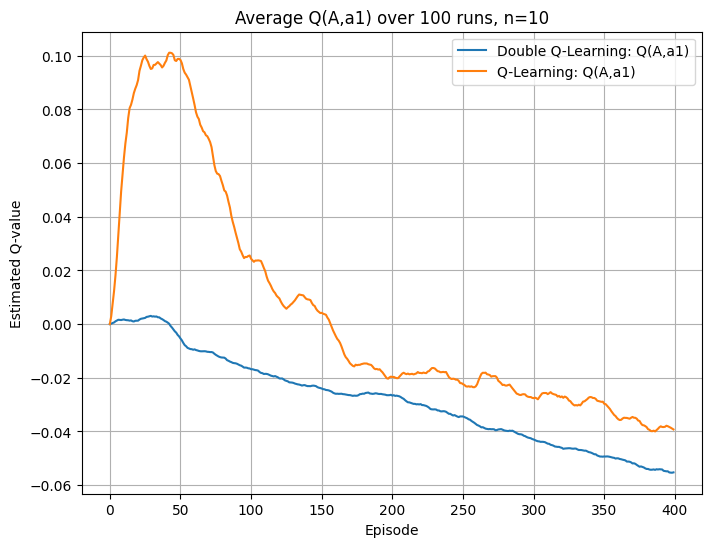

In [12]:
# -----------------------------------------------------------------------
# The MDP: States A,B and actions a1,a2,b1,...,bn (don't modify anything anymore, just run to get the graphs)
# -----------------------------------------------------------------------
@dataclass(frozen=True)
class P1State:
    """
    The MDP state, storing whether we are in "A" or "B".
    """
    name: str

class P1MDP(MarkovDecisionProcess[P1State, str]):
    
    def __init__(self, n: int):
        self.n = n

    def actions(self, state: NonTerminal[P1State]) -> Iterable[str]:
        """
        Return the actions available from this state.
          - if state is A => ["a1", "a2"]
          - if state is B => ["b1", ..., "bn"]
        """
        if state.state.name == "A":
            return ["a1", "a2"]
        else:
            return [f"b{i}" for i in range(1, self.n+1)]
    
    def step(
        self,
        state: NonTerminal[P1State],
        action: str
    ) -> Distribution[Tuple[State[P1State], float]]:
        """
        Return the distribution of (next state, reward) from (state, action):
          - A + a1 => reward 0, next state B
          - A + a2 => reward 0, next state terminal
          - B + b_i => reward ~ Normal(-0.1,1), next state terminal
        """
        if state.state.name == "A":
            if action == "a1":
                return Constant((NonTerminal(P1State("B")), 0.0))
            else:
                return Constant((Terminal(P1State("T")), 0.0))
        else:
            # For B + b_i => reward ~ N(-0.1,1), then terminal
            def sampler():
                r = np.random.normal(loc=-0.1, scale=1.0)
                return (Terminal(P1State("T")), r)
            return SampledDistribution(sampler)

def run_double_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Runs one 'chain' of Double Q-Learning for 'episodes' episodes,
    returning a list of Q-values for Q((A,a1)) at the end of each episode.
    """
    dq_iter = double_q_learning(mdp, start_dist, gamma)  # generator
    vals = []
    for _ in range(episodes):
        Q1 = next(dq_iter)
        # record Q1((A,a1)) each time
        qA1 = Q1((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def run_q_once(mdp, start_dist, gamma=1.0, episodes=400):
    """
    Same but for standard Q-Learning
    """
    q_iter = q_learning(mdp, start_dist, gamma)
    vals = []
    for _ in range(episodes):
        Q = next(q_iter)
        qA1 = Q((NonTerminal(P1State("A")), "a1"))
        vals.append(qA1)
    return vals

def main():
    # For reproducibility
    random.seed(0)
    np.random.seed(0)

    n = 10
    mdp = P1MDP(n)
    # Always start in A, as a NonTerminal
    start_dist = Constant(NonTerminal(P1State("A")))

    N_RUNS = 100
    N_EPISODES = 400

    all_dbl = []
    all_std = []

    for _ in range(N_RUNS):
        dbl_vals = run_double_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        std_vals = run_q_once(mdp, start_dist, gamma=1.0, episodes=N_EPISODES)
        all_dbl.append(dbl_vals)
        all_std.append(std_vals)

    arr_dbl = np.array(all_dbl)
    arr_std = np.array(all_std)

    avg_dbl = np.mean(arr_dbl, axis=0)
    avg_std = np.mean(arr_std, axis=0)

    plt.figure(figsize=(8,6))
    plt.plot(avg_dbl, label='Double Q-Learning: Q(A,a1)')
    plt.plot(avg_std, label='Q-Learning: Q(A,a1)')
    plt.xlabel('Episode')
    plt.ylabel('Estimated Q-value')
    plt.title('Average Q(A,a1) over 100 runs, n=10')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

### Writeup

**1. Comparison of behavior:**

Q-Learning's estimate of $Q(A, a_1)$ initially rises well above the true value of $-0.1$ due to maximization bias, then slowly corrects downward. Double Q-Learning's estimate stays much closer to the true value throughout training, converging faster and more stably.

**2. Why Q-Learning exhibits maximization bias:**

From state $B$, the agent must compute $\max_a Q(B, a)$ over $n = 10$ actions, each of which has true value $-0.1$ (since rewards are drawn from $\mathcal{N}(-0.1, 1)$). With finite samples, each $Q(B, b_i)$ is a noisy estimate of $-0.1$. Taking the maximum over 10 such noisy estimates produces a systematic positive bias — the maximum of independent noisy estimates of a common mean is biased upward. This inflates $Q(A, a_1)$, making the agent incorrectly prefer $a_1$ (go to $B$) over $a_2$ (which has true value $0$).

**3. Advantages and drawbacks of Double Q-Learning:**

*Advantages:*
- Eliminates maximization bias by decoupling action selection (argmax) from value evaluation. When Q1 selects the best action, Q2 evaluates it with an independent estimate, so the selection bias does not carry over.
- Leads to better policies in environments where many actions share similar values and noise causes spurious maxima.

*Drawbacks:*
- Each Q-table receives only half the updates, so individual estimates converge more slowly (higher variance per table).
- Requires twice the memory for storing two Q-tables.
- In environments where maximization bias is not a concern (e.g., deterministic rewards or very few actions), double Q-learning adds complexity without meaningful benefit.